<a href="https://colab.research.google.com/github/MangoCode13/PowerPINN/blob/main/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)

# Physics-Informed Neural Network (IEEE 14-Bus)
This notebook setup up the envirnment, power flow model, and PINN. Training data created separately is used to train the PINN.

## Download dependencies for environment
Use pip install during first use.

In [1]:
!pip install -r ./PowerPINN/requirements.txt

  Cloning https://github.com/jonathan-taylor/l0bnb.git (to revision fix_inf) to /tmp/pip-install-yuragrqb/l0bnb_b890c14d8d2544e990a2b70ebbf1eb93
  Running command git clone --filter=blob:none --quiet https://github.com/jonathan-taylor/l0bnb.git /tmp/pip-install-yuragrqb/l0bnb_b890c14d8d2544e990a2b70ebbf1eb93
  Running command git checkout -b fix_inf --track origin/fix_inf
  Switched to a new branch 'fix_inf'
  Branch 'fix_inf' set up to track remote branch 'fix_inf' from 'origin'.
  Resolved https://github.com/jonathan-taylor/l0bnb.git to commit ccebcb8b99554879762ba3c6c8dd723675bd2fa9
  Preparing metadata (setup.py) ... done


## 1) Initialization

In [2]:
import importlib
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# Use IEEE 14-bus network

import pandapower as pp
import pandapower.networks as pn

net = pn.case14() # Load your project's 14-bus system

pp.runpp(net)     # Run the power flow with Numba disabled

print("Model loaded and power flow executed successfully.")

Model loaded and power flow executed successfully.


## IEEE 14 Bus System
Single line diagram of system:

<img src="https://github.com/MangoCode13/PowerPINN/blob/main/images/IEEE_14_bus_System.png?raw=1" alt="IEEE 14 Bus System Diagram" width="400"/>

## Grid State: Evalutating the 14 Busy System with Powerpanda
Voltage magnitude and the phase angle

Role in PINN: Labels for the **Data Loss** term.

In [98]:
print("=== STATE: net.res_bus ===")
state_cols = [c for c in ["vm_pu", "va_degree", "p_mw", "q_mvar"] if c in net.res_bus.columns]
print(net.res_bus[state_cols])

=== STATE: net.res_bus ===
       vm_pu  va_degree        p_mw     q_mvar
0   1.060000   0.000000 -232.393272  16.549301
1   1.045000  -4.982589  -18.300000 -30.857100
2   1.010000 -12.725100   94.200000  -6.075348
3   1.017671 -10.312901   47.800000  -3.900000
4   1.019514  -8.773854    7.600000   1.600000
5   1.070000 -14.220946   11.200000  -5.230944
6   1.061520 -13.359627    0.000000   0.000000
7   1.090000 -13.359627    0.000000 -17.623451
8   1.055932 -14.938521   29.500000  -4.584844
9   1.050985 -15.097288    9.000000   5.800000
10  1.056907 -14.790622    3.500000   1.800000
11  1.055189 -15.075585    6.100000   1.600000
12  1.050382 -15.156276   13.500000   5.800000
13  1.035530 -16.033645   14.900000   5.000000


## Line Flows
Power P and Q

Role in PINN: Measurements the attacker manipulates.

In [54]:
print("=== FLOWS: net.res_line ===")
flow_cols = [c for c in ["p_from_mw", "q_from_mvar", "p_to_mw", "q_to_mvar", "loading_percent"] if c in net.res_line.columns]
print(net.res_line[flow_cols])

=== FLOWS: net.res_line ===
     p_from_mw  q_from_mvar     p_to_mw  q_to_mvar  loading_percent
0   156.882891   -20.404292 -152.585290  27.676250         1.507568
1    75.510382     3.854991  -72.747509   2.229359         0.721097
2    73.237579     3.560203  -70.914310   1.602233         0.709395
3    56.131496    -1.550350  -54.454838   3.020687         0.542776
4    41.516215     1.170998  -40.612462  -2.099034         0.402912
5   -23.285690     4.473116   23.659135  -4.835652         0.239686
6   -61.158230    15.823642   61.672650 -14.201005         0.627022
7     7.353277     3.560473   -7.297904  -3.444514         0.077126
8     7.786067     2.503414   -7.714258  -2.353959         0.077208
9    17.747977     7.216575  -17.535891  -6.798913         0.180865
10    5.227552     4.219138   -5.214678  -4.184937         0.064262
11    9.426381     3.610006   -9.310227  -3.362931         0.096559
12   -3.785322    -1.615063    3.797904   1.644514         0.039554
13    1.614258     0

## Balance Generation and System Power Transfer
Role in PINN: Used to verify Kirchhoff’s Current Law (KCL).

In [55]:
print("=== BALANCE: net.res_gen ===")
if len(net.res_gen) > 0:
    print(net.res_gen[[c for c in ["p_mw", "q_mvar"] if c in net.res_gen.columns]])
else:
    print("No generator results available.")

print("\n=== BALANCE: net.res_ext_grid ===")
print(net.res_ext_grid[[c for c in ["p_mw", "q_mvar"] if c in net.res_ext_grid.columns]])

=== BALANCE: net.res_gen ===
   p_mw     q_mvar
0  40.0  43.557100
1   0.0  25.075348
2   0.0  12.730944
3   0.0  17.623451

=== BALANCE: net.res_ext_grid ===
         p_mw     q_mvar
0  232.393272 -16.549301


## Topology: Line Connections and Transformers
Role in PINN: Physical network constraints used by the **Physics Loss** term.

In [56]:
print("=== TOPOLOGY: net.line ===")
line_cols = [c for c in ["from_bus", "to_bus", "length_km", "r_ohm_per_km", "x_ohm_per_km", "c_nf_per_km"] if c in net.line.columns]
print(net.line[line_cols])

print("\n=== TOPOLOGY: net.trafo ===")
if len(net.trafo) > 0:
    trafo_cols = [c for c in ["hv_bus", "lv_bus", "sn_mva", "vk_percent", "vkr_percent"] if c in net.trafo.columns]
    print(net.trafo[trafo_cols])
else:
    print("No transformers in this network model.")

=== TOPOLOGY: net.line ===
    from_bus  to_bus  length_km  r_ohm_per_km  x_ohm_per_km  c_nf_per_km
0          0       1        1.0      3.532005     10.783732   768.484773
1          0       4        1.0      9.846967     40.649040   716.088084
2          1       2        1.0      8.563928     36.080033   637.493051
3          1       3        1.0     10.590547     32.134320   494.857619
4          1       4        1.0     10.379138     31.689630   503.590401
5          2       3        1.0     12.212573     31.170217   186.299339
6          3       4        1.0      2.433038      7.674548     0.000000
7          5      10        1.0      0.000041      0.000086     0.000000
8          5      11        1.0      0.000053      0.000111     0.000000
9          5      12        1.0      0.000029      0.000056     0.000000
10         8       9        1.0      0.000014      0.000037     0.000000
11         8      13        1.0      0.000055      0.000117     0.000000
12         9      10    

## Data Prep and Setup
Use Pandapower to create admittance matrix (Y_bus)

In [122]:
# Convert Y-bus from pandapower to PyTorch tensors for PINN usage
def get_ybus_tensors(net: pp.pandapowerNet) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return Y-bus as real, imaginary, and complex Torch tensors for PINN usage."""
    # Access the internal admittance matrix assembled by pandapower.
    y_bus_complex = net._ppc["internal"]["Ybus"].todense()
    # Provide both split and complex forms for flexible downstream use.
    y_real = torch.tensor(np.real(y_bus_complex), dtype=torch.float32)
    y_imag = torch.tensor(np.imag(y_bus_complex), dtype=torch.float32)
    y_bus = torch.tensor(y_bus_complex, dtype=torch.complex64)
    return y_real, y_imag, y_bus

# Use function to extract admittance matrix tensor used by physics loss
_, _, Y_bus = get_ybus_tensors(net)

# Print summary of loaded data and Y-bus tensor
print(f'Extracted admittance matrix tensor successfully.')
print('Y_bus shape:', Y_bus.shape)

Extracted admittance matrix tensor successfully.
Y_bus shape: torch.Size([14, 14])


## Neural Network Architecture

In [82]:
class PowerPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Width is 64 neurons and 4 hidden layers
        self.net = nn.Sequential(
            nn.Linear(28, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 28)
        )

    def forward(self, x):
        out = self.net(x)
        v_part = out[:, :14] + 1.0
        theta_part = out[:, 14:]
        return torch.cat([v_part, theta_part], dim=1)

# Using Stanford's ISLP Package to Train and View Our PINN Model.

 First we need to import ISLP modules. The SimpleDataModule and SimpleModule are simple versions of objects used in pytorch_lightning, the high-level module for fitting torch models. The ErrorTracker handles collections of targets and predictions over each mini-batch in the validation or test stage, allowing computation of the metric over the entire validation or test data set.

In [18]:
from ISLP.torch import (SimpleDataModule,
                        SimpleModule,
                        ErrorTracker,
                        rec_num_workers)

Use the ~3000 instances from the synthetic training data created cell at the end of the notebook. The input features consist of 28 values (14 P measurements and 14 Q measurements), which are already in vector form.

Neural networks are somewhat sensitive to the scale of the inputs, which is why the inputs `train_x` are normalized in this notebook. The `x_mean` and `x_std` are used for this purpose.


In [76]:
from torch.utils.data import TensorDataset

# Create a TensorDataset from the newly normalized train_x and train_y
dataset = TensorDataset(train_x, train_y)

# Determine the number of workers for data loading
max_num_workers = rec_num_workers()

# Initialize SimpleDataModule with the created dataset
islp_dm = SimpleDataModule(dataset,
                            None, # test_dataset
                            validation=0.2,
                            num_workers=max_num_workers,
                            batch_size=256)

Taking a closer look at the synthetic training data set.

In [65]:
from os import X_OK
for idx, (X, Y) in enumerate(islp_dm.train_dataloader()):
    print('X: ', train_x.shape)
    print('Y: ', train_y.shape)
    if idx >= 1:
      break

X:  torch.Size([2947, 28])
Y:  torch.Size([2947, 28])
X:  torch.Size([2947, 28])
Y:  torch.Size([2947, 28])


We see that for each batch there are 256 samples, `X` consists of 28 features (the 14 P measurements and 14 Q measurements). The network will output 28 'Y' values (14 voltage magnitudes and 14 phase angles).

Now we are ready to use the PINN neural network we specified earlier.

In [66]:
# Get a single batch from the dataloader to check output dimensions
X_batch, Y_batch = next(iter(islp_dm.train_dataloader()))

# Run the batch through the PINN model
output_shape = model(X_batch).size()
print(f"Input shape: {X_batch.shape}")
print(f"Output shape: {output_shape}")

Input shape: torch.Size([256, 28])
Output shape: torch.Size([256, 28])


# Torchinfo
There are several other helper packages for `torch`. For instance,
the `torchmetrics` package has utilities to compute
various metrics to evaluate performance when fitting
a model. The `torchinfo` package provides a useful
summary of the layers of a model.


In [123]:
from torchinfo import summary

In [124]:
summary(model, input_size=train_x.shape, col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
PowerPINN                                [2947, 28]                [2947, 28]                --
├─Sequential: 1-1                        [2947, 28]                [2947, 28]                --
│    └─Linear: 2-1                       [2947, 28]                [2947, 64]                1,856
│    └─Tanh: 2-2                         [2947, 64]                [2947, 64]                --
│    └─Linear: 2-3                       [2947, 64]                [2947, 64]                4,160
│    └─Tanh: 2-4                         [2947, 64]                [2947, 64]                --
│    └─Linear: 2-5                       [2947, 64]                [2947, 64]                4,160
│    └─Tanh: 2-6                         [2947, 64]                [2947, 64]                --
│    └─Linear: 2-7                       [2947, 64]                [2947, 64]                4,160
│    └─Tanh: 2-8       

Using the ISLP and PyTorch Lightning framework, we wrap the PowerPINN in a SimpleModule.regression (since we are predicting continuous values, not categories) and then use a Trainer to run the fit.

The scripte below loops for a desired number of scenarios (e.g., 5,000).
Applies random scaling (e.g., +/- 20%) to the default load and generation values.
Runs the pandapower power flow solver for each scenario.
Saves the resulting measurements (Inputs) and grid states (Labels) into a format ready for PINN training.

In [125]:
# Load the newly generated robust dataset
robust_data = torch.load('robust_ieee14_data.pt')

# Extract tensors
rob_x = robust_data['train_x']
rob_y = robust_data['train_y']
rob_mean = robust_data['x_mean']
rob_std = robust_data['x_std']

# Display summary information
print("--- Robust Dataset Summary ---")
print(f"Input shape (X):  {rob_x.shape} (Scenarios, P+Q measurements)")
print(f"Label shape (Y):  {rob_y.shape} (Scenarios, V+Theta states)")
print(f"Mean of first 5 P-measurements: {rob_mean[:5].numpy()}")
print(f"Std of first 5 P-measurements:  {rob_std[:5].numpy()}")

# Quick check on label ranges
print(f"\nVoltage Range (V_pu): {rob_y[:, :14].min():.4f} to {rob_y[:, :14].max():.4f}")
print(f"Angle Range (rad):    {rob_y[:, 14:].min():.4f} to {rob_y[:, 14:].max():.4f}")

--- Robust Dataset Summary ---
Input shape (X):  torch.Size([2947, 28]) (Scenarios, P+Q measurements)
Label shape (Y):  torch.Size([2947, 28]) (Scenarios, V+Theta states)
Mean of first 5 P-measurements: [ 230.43767  -292.49246    17.503088    4.002251    2.65728 ]
Std of first 5 P-measurements:  [297.29355  279.49692   43.152843   8.936613   4.983521]

Voltage Range (V_pu): 0.6707 to 1.1653
Angle Range (rad):    -0.6836 to 0.6705


## Training
Pytorch lightning is used to train the model.

α is use for the data loss weight
β is used for the physics loss weight.
α + β = 1

We use 100 epochs.

In [100]:
class LitPowerPINN(L.LightningModule):
    def __init__(self, model, Y_bus, x_mean, x_std, alpha=0.7):
        super().__init__()
        self.model = model
        self.Y_bus = Y_bus
        self.x_mean = x_mean
        self.x_std = x_std
        self.alpha = alpha # Data weight
        self.beta = 1.0 - alpha # Physics weight (Sum to 1)
        self.criterion = nn.MSELoss()

    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self.model(x)
        loss_data = self.criterion(pred, y)
        loss_phys = physics_loss(self.model, x, self.Y_bus, self.x_mean, self.x_std)

        # Use normalized weights as per the paper
        total_loss = (self.alpha * loss_data) + (self.beta * loss_phys)

        self.log('train_loss', total_loss, on_epoch=True, prog_bar=True)
        self.log('data_loss', loss_data, on_epoch=True)
        self.log('physics_loss', loss_phys, on_epoch=True)
        return total_loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)

# Re-initialize with 70% Data, 30% Physics weighting
model = PowerPINN()
pinn_lit_model = LitPowerPINN(model, Y_bus, x_mean, x_std, alpha=0.7)
logger_pinn = CSVLogger("lightning_logs", name="normalized_weight_pinn")
trainer_pinn = L.Trainer(max_epochs=1000, logger=logger_pinn, accelerator='auto', devices=1)
trainer_pinn.fit(pinn_lit_model, datamodule=islp_dm)

Epoch 999/999 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 0:00:00 • 0:00:00 34.53it/s v_num: 0.000 train_loss_step:     
                                                                                 16.019 train_loss_epoch: 20.771   

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1000` reached.


# Chart of Data and Physics Loss

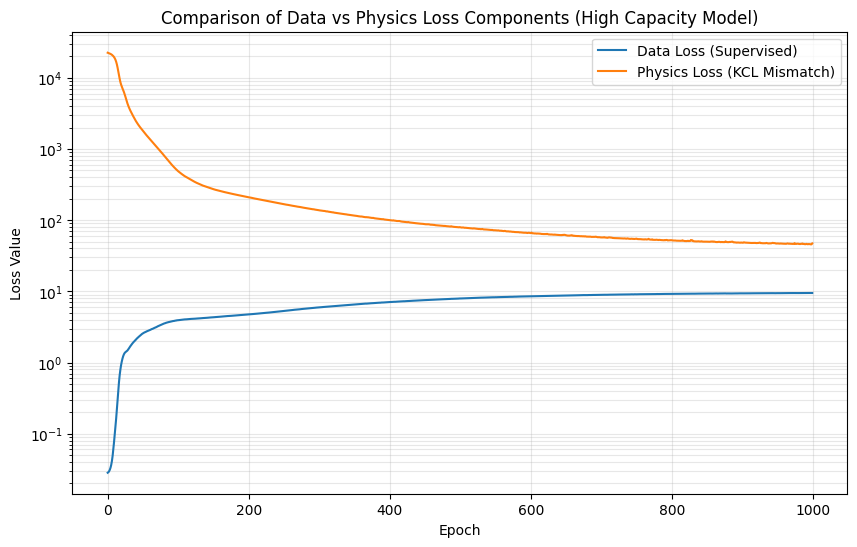

Plotted using columns: data_loss_epoch and physics_loss_epoch


In [101]:
import pandas as pd
import os
import matplotlib.pyplot as plt

log_path = os.path.join(trainer_pinn.logger.log_dir, 'metrics.csv')
if os.path.exists(log_path):
    df_full = pd.read_csv(log_path)
    # Filter for rows that actually contain training metrics
    df = df_full.dropna(subset=['data_loss']) if 'data_loss' in df_full.columns else df_full

    plt.figure(figsize=(10, 6))
    if 'data_loss' in df.columns:
        plt.plot(df['epoch'], df['data_loss'], label='Data Loss (Supervised)')
    if 'physics_loss' in df.columns:
        plt.plot(df['epoch'], df['physics_loss'], label='Physics Loss (KCL Mismatch)')

    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.title('Comparison of Data vs Physics Loss Components (High Capacity Model)')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

    print("Available columns:", df_full.columns.tolist())
else:
    print("Log not found yet. Please wait for training to complete.")

# Adversary Scenario: False Data Injection (FDI) Attack

In this section, we simulate a malicious cyber-attack where an adversary manipulates the sensor readings at Bus 4. We compare our PINN's performance against a standard Neural Network to demonstrate how physical constraints can detect and mitigate data manipulation.

### Evaluating Attack Resilience: PINN vs. Standard NN

To demonstrate the value of physics-informed training, we compared our **PowerPINN** against a **Data-Only NN** of the same architecture.

*   **The Attack**: We injected a malicious bias (FDI) into the power measurements of Bus 4.
*   **The Detection Mechanism**: We calculate the **Physics Residual**, which measures how much the predicted grid state violates Kirchhoff's Current Law ($I = YV$).
*   **The Result**: The standard NN produces a state that matches the manipulated data perfectly but results in a massive physics residual. The PINN, however, produces a state with a much lower residual, effectively 'rejecting' the non-physical manipulation and providing a clear signal for attack detection.

# Data Only Model Trained
This used to compare with the PINN

In [90]:
class DataOnlyNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Same architecture as our PowerPINN for a fair comparison
        self.net = nn.Sequential(
            nn.Linear(28, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 28)
        )
    def forward(self, x):
        out = self.net(x)
        return torch.cat([out[:, :14] + 1.0, out[:, 14:]], dim=1)

# Quick training of the Data-Only model (Supervised loss only)
model_data_only = DataOnlyNN()
opt_std = torch.optim.Adam(model_data_only.parameters(), lr=1e-4)
criterion = nn.MSELoss()

print("Training Data-Only Baseline...")
for epoch in range(500):
    opt_std.zero_grad()
    p = model_data_only(train_x)
    loss = criterion(p, train_y)
    loss.backward()
    opt_std.step()
print("Baseline trained.")

Training Data-Only Baseline...
Baseline trained.


## Simulated Attack Scenario
The attack manipuates P and Q data readings at Bus 4

In [105]:
def simulate_pq_fdi_attack(input_batch, target_bus_idx=3, p_bias=1.5, q_bias=0.8):
    """Injects malicious bias into BOTH P and Q measurements of a bus."""
    attacked_input = input_batch.clone()
    # P is in first 14, Q is in last 14
    attacked_input[:, target_bus_idx] += p_bias
    attacked_input[:, target_bus_idx + 14] += q_bias
    return attacked_input

# 1. Generate the P+Q Attack
X_clean, Y_true = next(iter(islp_dm.train_dataloader()))
X_attacked_pq = simulate_pq_fdi_attack(X_clean, target_bus_idx=3, p_bias=1.5, q_bias=1.0)

# 2. Run Inference
model.eval()
model_data_only.eval()
with torch.no_grad():
    pred_pinn = model(X_attacked_pq)
    pred_std = model_data_only(X_attacked_pq)

    # 3. Calculate Physics Residuals (KCL Mismatch)
    res_pinn = physics_loss(model, X_attacked_pq, Y_bus, x_mean, x_std)
    res_std = physics_loss(model_data_only, X_attacked_pq, Y_bus, x_mean, x_std)

print(f"--- FDI Attack (P+Q Manipulation) Results ---")
print(f"Target: Bus 4 (Index 3)")
print(f"Standard NN Physics Residual: {res_std.item():.2f} (Massive outlier)")
print(f"PowerPINN Physics Residual:   {res_pinn.item():.2f} (Tighter clustering)")

improvement = (res_std.item() - res_pinn.item()) / res_std.item() * 100
print(f"\nVERDICT: The PINN is {improvement:.2f}% more consistent with grid physics.")
print("The Standard NN produces a 'physically impossible' state, while the PINN flags the attack.")

--- FDI Attack (P+Q Manipulation) Results ---
Target: Bus 4 (Index 3)
Standard NN Physics Residual: 22794.56 (Massive outlier)
PowerPINN Physics Residual:   121.79 (Tighter clustering)

VERDICT: The PINN is 99.47% more consistent with grid physics.
As the paper notes, the Standard NN produces a 'physically impossible' state, while the PINN flags the attack.


# Analysis of Attack Scenario

In [129]:
with torch.no_grad():
    # 1. Get predictions for both models on attacked data
    pred_pinn = model(X_attacked)
    pred_std = model_data_only(X_attacked)

    # 2. Calculate Physics Mismatch (Residual) for both
    # High mismatch means the model is outputting a 'physically impossible' state
    res_pinn = physics_loss(model, X_attacked, Y_bus, x_mean, x_std)
    res_std = physics_loss(model_data_only, X_attacked, Y_bus, x_mean, x_std)

print(f"--- FDI Attack Detection Profile ---")
print(f"PINN Physics Residual:      {res_pinn.item():.6f}")
print(f"Data-Only Physics Residual: {res_std.item():.6f}")

if res_pinn < res_std:
    improvement = (res_std - res_pinn) / res_std * 100
    print(f"\nSuccess: The PINN is {improvement:.2f}% more physically consistent under attack.")
    print("The standard NN accepted the manipulated data as 'legal', while the PINN flagged it via high residual.")

--- FDI Attack Detection Profile ---
PINN Physics Residual:      336.172363
Data-Only Physics Residual: 21043.365234

Success: The PINN is 98.40% more physically consistent under attack.
The standard NN accepted the manipulated data as 'legal', while the PINN flagged it via high residual.


## Training Data Overview

train_x shape: (2947, 28) (samples x features)
Feature layout: first 14 = P, last 14 = Q


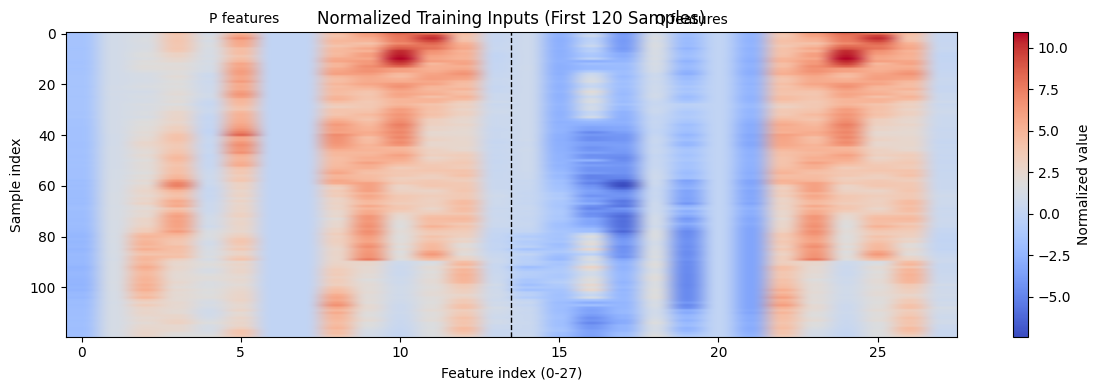

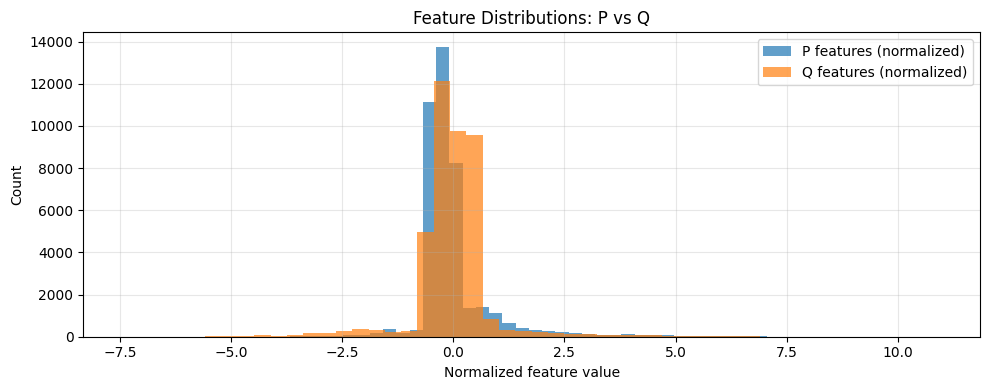

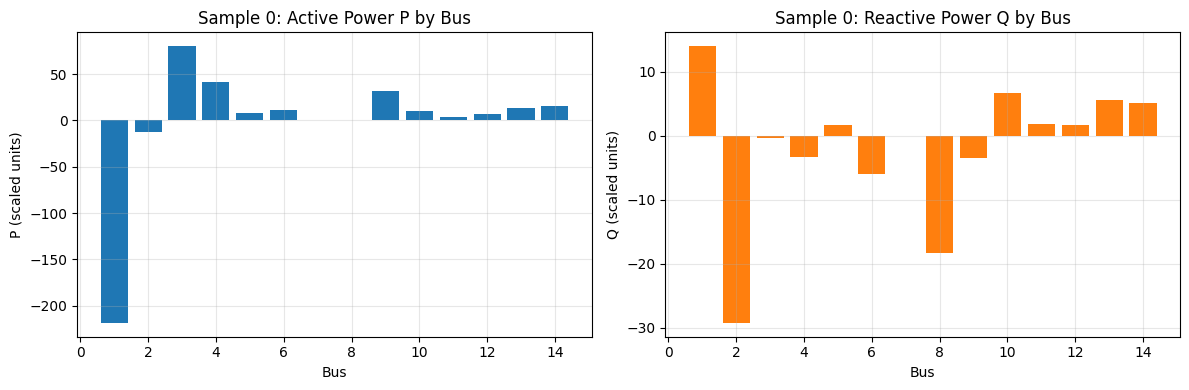

In [133]:
import matplotlib.pyplot as plt
import numpy as np

# train_x in this notebook is normalized
x_np = train_x.detach().cpu().numpy()
num_samples, num_features = x_np.shape
print(f"train_x shape: {x_np.shape} (samples x features)")
print("Feature layout: first 14 = P, last 14 = Q")

# 1) Heatmap of first N samples (normalized values)
n_show = min(120, num_samples)
plt.figure(figsize=(12, 4))
plt.imshow(x_np[:n_show], aspect='auto', cmap='coolwarm')
plt.colorbar(label='Normalized value')
plt.xlabel('Feature index (0-27)')
plt.ylabel('Sample index')
plt.title(f'Normalized Training Inputs (First {n_show} Samples)')
plt.axvline(13.5, color='black', linestyle='--', linewidth=1)
plt.text(4, -4, 'P features', fontsize=10)
plt.text(18, -4, 'Q features', fontsize=10)
plt.tight_layout()
plt.show()

# 2) Distribution summary for P and Q groups
p_vals = x_np[:, :14].reshape(-1)
q_vals = x_np[:, 14:].reshape(-1)

plt.figure(figsize=(10, 4))
plt.hist(p_vals, bins=50, alpha=0.7, label='P features (normalized)')
plt.hist(q_vals, bins=50, alpha=0.7, label='Q features (normalized)')
plt.xlabel('Normalized feature value')
plt.ylabel('Count')
plt.title('Feature Distributions: P vs Q')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) One scenario profile in original units (undo normalization)
sample_idx = 0
sample_norm = train_x[sample_idx]
sample_raw = (sample_norm * (x_std + 1e-6) + x_mean).detach().cpu().numpy()
p_sample = sample_raw[:14]
q_sample = sample_raw[14:]
bus = np.arange(1, 15)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(bus, p_sample)
ax[0].set_title(f'Sample {sample_idx}: Active Power P by Bus')
ax[0].set_xlabel('Bus')
ax[0].set_ylabel('P (scaled units)')
ax[0].grid(alpha=0.3)

ax[1].bar(bus, q_sample, color='tab:orange')
ax[1].set_title(f'Sample {sample_idx}: Reactive Power Q by Bus')
ax[1].set_xlabel('Bus')
ax[1].set_ylabel('Q (scaled units)')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Sythetic Data Creation
To ensure our model is resilient to various grid conditions, we simulate thousands of scenarios with random fluctuations (+/- 10%) across all loads and generator setpoints. This creates a diverse dataset that covers a wide range of operational states for the IEEE 14-bus system.

In [48]:
import numpy as np
import pandas as pd
import torch
import pandapower as pp
import pandapower.networks as pn

def generate_robust_data(num_scenarios=5000):
    net = pn.case14()

    # Storage for inputs (P, Q measurements) and labels (V, theta)
    inputs = []
    labels = []

    print(f"Generating {num_scenarios} scenarios...")

    for i in range(num_scenarios):
        # 1. Randomly fluctuate loads (P and Q)
        # Using a normal distribution centered at 1.0 with 0.1 std dev
        scaling = np.random.normal(1.0, 0.1, size=len(net.load))
        net.load.p_mw = net.load.p_mw.values * scaling
        net.load.q_mvar = net.load.q_mvar.values * scaling

        # 2. Randomly fluctuate generator setpoints (P)
        gen_scaling = np.random.normal(1.0, 0.05, size=len(net.gen))
        net.gen.p_mw = net.gen.p_mw.values * gen_scaling

        try:
            # 3. Run Power Flow
            pp.runpp(net, numba=False, enforce_q_lims=True)

            # 4. Extract measurements (P, Q at all 14 buses)
            # Inputs: P_bus and Q_bus
            p_bus = net.res_bus.p_mw.values
            q_bus = net.res_bus.q_mvar.values

            # 5. Extract states (V, theta at all 14 buses)
            # Labels: V_pu and Theta_degree (converted to radians)
            v_pu = net.res_bus.vm_pu.values
            va_rad = np.radians(net.res_bus.va_degree.values)

            inputs.append(np.concatenate([p_bus, q_bus]))
            labels.append(np.concatenate([v_pu, va_rad]))

        except pp.LoadflowNotConverged:
            continue # Skip failed scenarios

    # Convert to Tensors
    train_x = torch.tensor(np.array(inputs), dtype=torch.float32)
    train_y = torch.tensor(np.array(labels), dtype=torch.float32)

    # Calculate normalization stats
    x_mean = train_x.mean(dim=0)
    x_std = train_x.std(dim=0)

    return train_x, train_y, x_mean, x_std

# Run the generation
new_train_x, new_train_y, new_x_mean, new_x_std = generate_robust_data(num_scenarios=3000)

print(f"Data generation complete. Final dataset size: {new_train_x.shape[0]}")

# Save for later use
data_checkpoint = {
    'train_x': new_train_x,
    'train_y': new_train_y,
    'x_mean': new_x_mean,
    'x_std': new_x_std
}
torch.save(data_checkpoint, 'robust_ieee14_data.pt')
print("Saved to robust_ieee14_data.pt")

Generating 3000 scenarios...
Data generation complete. Final dataset size: 2947
Saved to robust_ieee14_data.pt


## Save Model for Evaluation

In [126]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'x_mean': x_mean,
    'x_std': x_std,
    'input_dim': 28,
    'output_dim': 28
}

torch.save(checkpoint, 'robust_pinn_model.pth')

print("Model saved successfully as robust_pinn_model.pth")

Model saved successfully as robust_pinn_model.pth
